In [ ]:
!pip install matplotlib pandas py-raccoon

In [2]:
import py_raccoon as pr
import networkx as nx
import pandas as pd
import numpy as np

In [3]:
G = nx.karate_club_graph()

In [ ]:
# Requires scikit-sparse and SuiteSparse
log_counts, is_zero, sampled = pr.estimate_cycle_count(G, approx_prob=False, samples=1000)
sampled_counts = np.exp2(log_counts)
sampled_counts[is_zero] = 0

In [5]:
log_counts_approx, is_zero, sampled = pr.estimate_cycle_count(G, approx_prob=True, samples=1000)
sampled_counts_approx = np.exp2(log_counts)
sampled_counts_approx[is_zero] = 0

In [6]:
real_counts = np.zeros(sampled_counts.shape, dtype=np.int32)
for c in nx.simple_cycles(G):
    real_counts[len(c)] += 1

,estimation,approx_estimation,correct
0,0,0,0
1,0,0,0
2,0,0,0
3,45,57,45
4,156,209,154
5,369,608,374
6,951,1877,969
7,2894,5925,2746
8,7474,17797,7507
9,17112,41437,17625


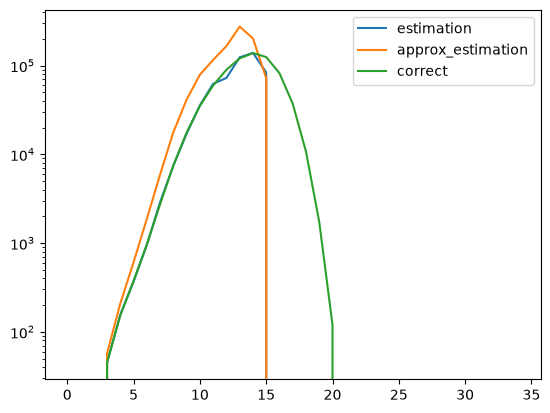

In [9]:
df = pd.DataFrame({'estimation': np.rint(sampled_counts).astype(np.int32), 'approx_estimation': np.rint(sampled_counts_approx).astype(np.int32), 'correct': real_counts})
df.plot(logy=True)
df